In [6]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
base_dir = "/home/users/mendrika/NCAST/Output/optimisation/Dakar"

csv_files = glob.glob(
    f"{base_dir}/**/*.csv",
    recursive=True
)

dfs = []

for file in csv_files:

    df = pd.read_csv(file)

    dfs.append(df)

results = pd.concat(
    dfs,
    ignore_index=True
)

In [8]:
print(results)

   model  lead_time       C class_weight  train_auc   val_auc  test_auc  \
0     LR          3    0.01     balanced   0.879112  0.938514  0.857421   
1     LR          6    0.01     balanced   0.783413  0.861586  0.755624   
2     LR          1    0.01          NaN   0.960321  0.977939  0.955923   
3    SVM          1  100.00     balanced   0.964446  0.974408  0.957932   
4    SVM          6    0.10          NaN   0.782145  0.865068  0.745549   
5    SVM          3  100.00     balanced   0.879550  0.937483  0.855442   
6    XGB          3     NaN          NaN   0.969456  0.952591  0.891744   
7    XGB          1     NaN          NaN   0.989902  0.985900  0.974685   
8    XGB          6     NaN          NaN   0.965618  0.875765  0.786966   
9    MLP          1     NaN          NaN   0.964723  0.981847  0.960046   
10   MLP          6     NaN          NaN   0.790493  0.863509  0.758832   
11   MLP          3     NaN          NaN   0.879436  0.936541  0.859663   
12    RF          1     N

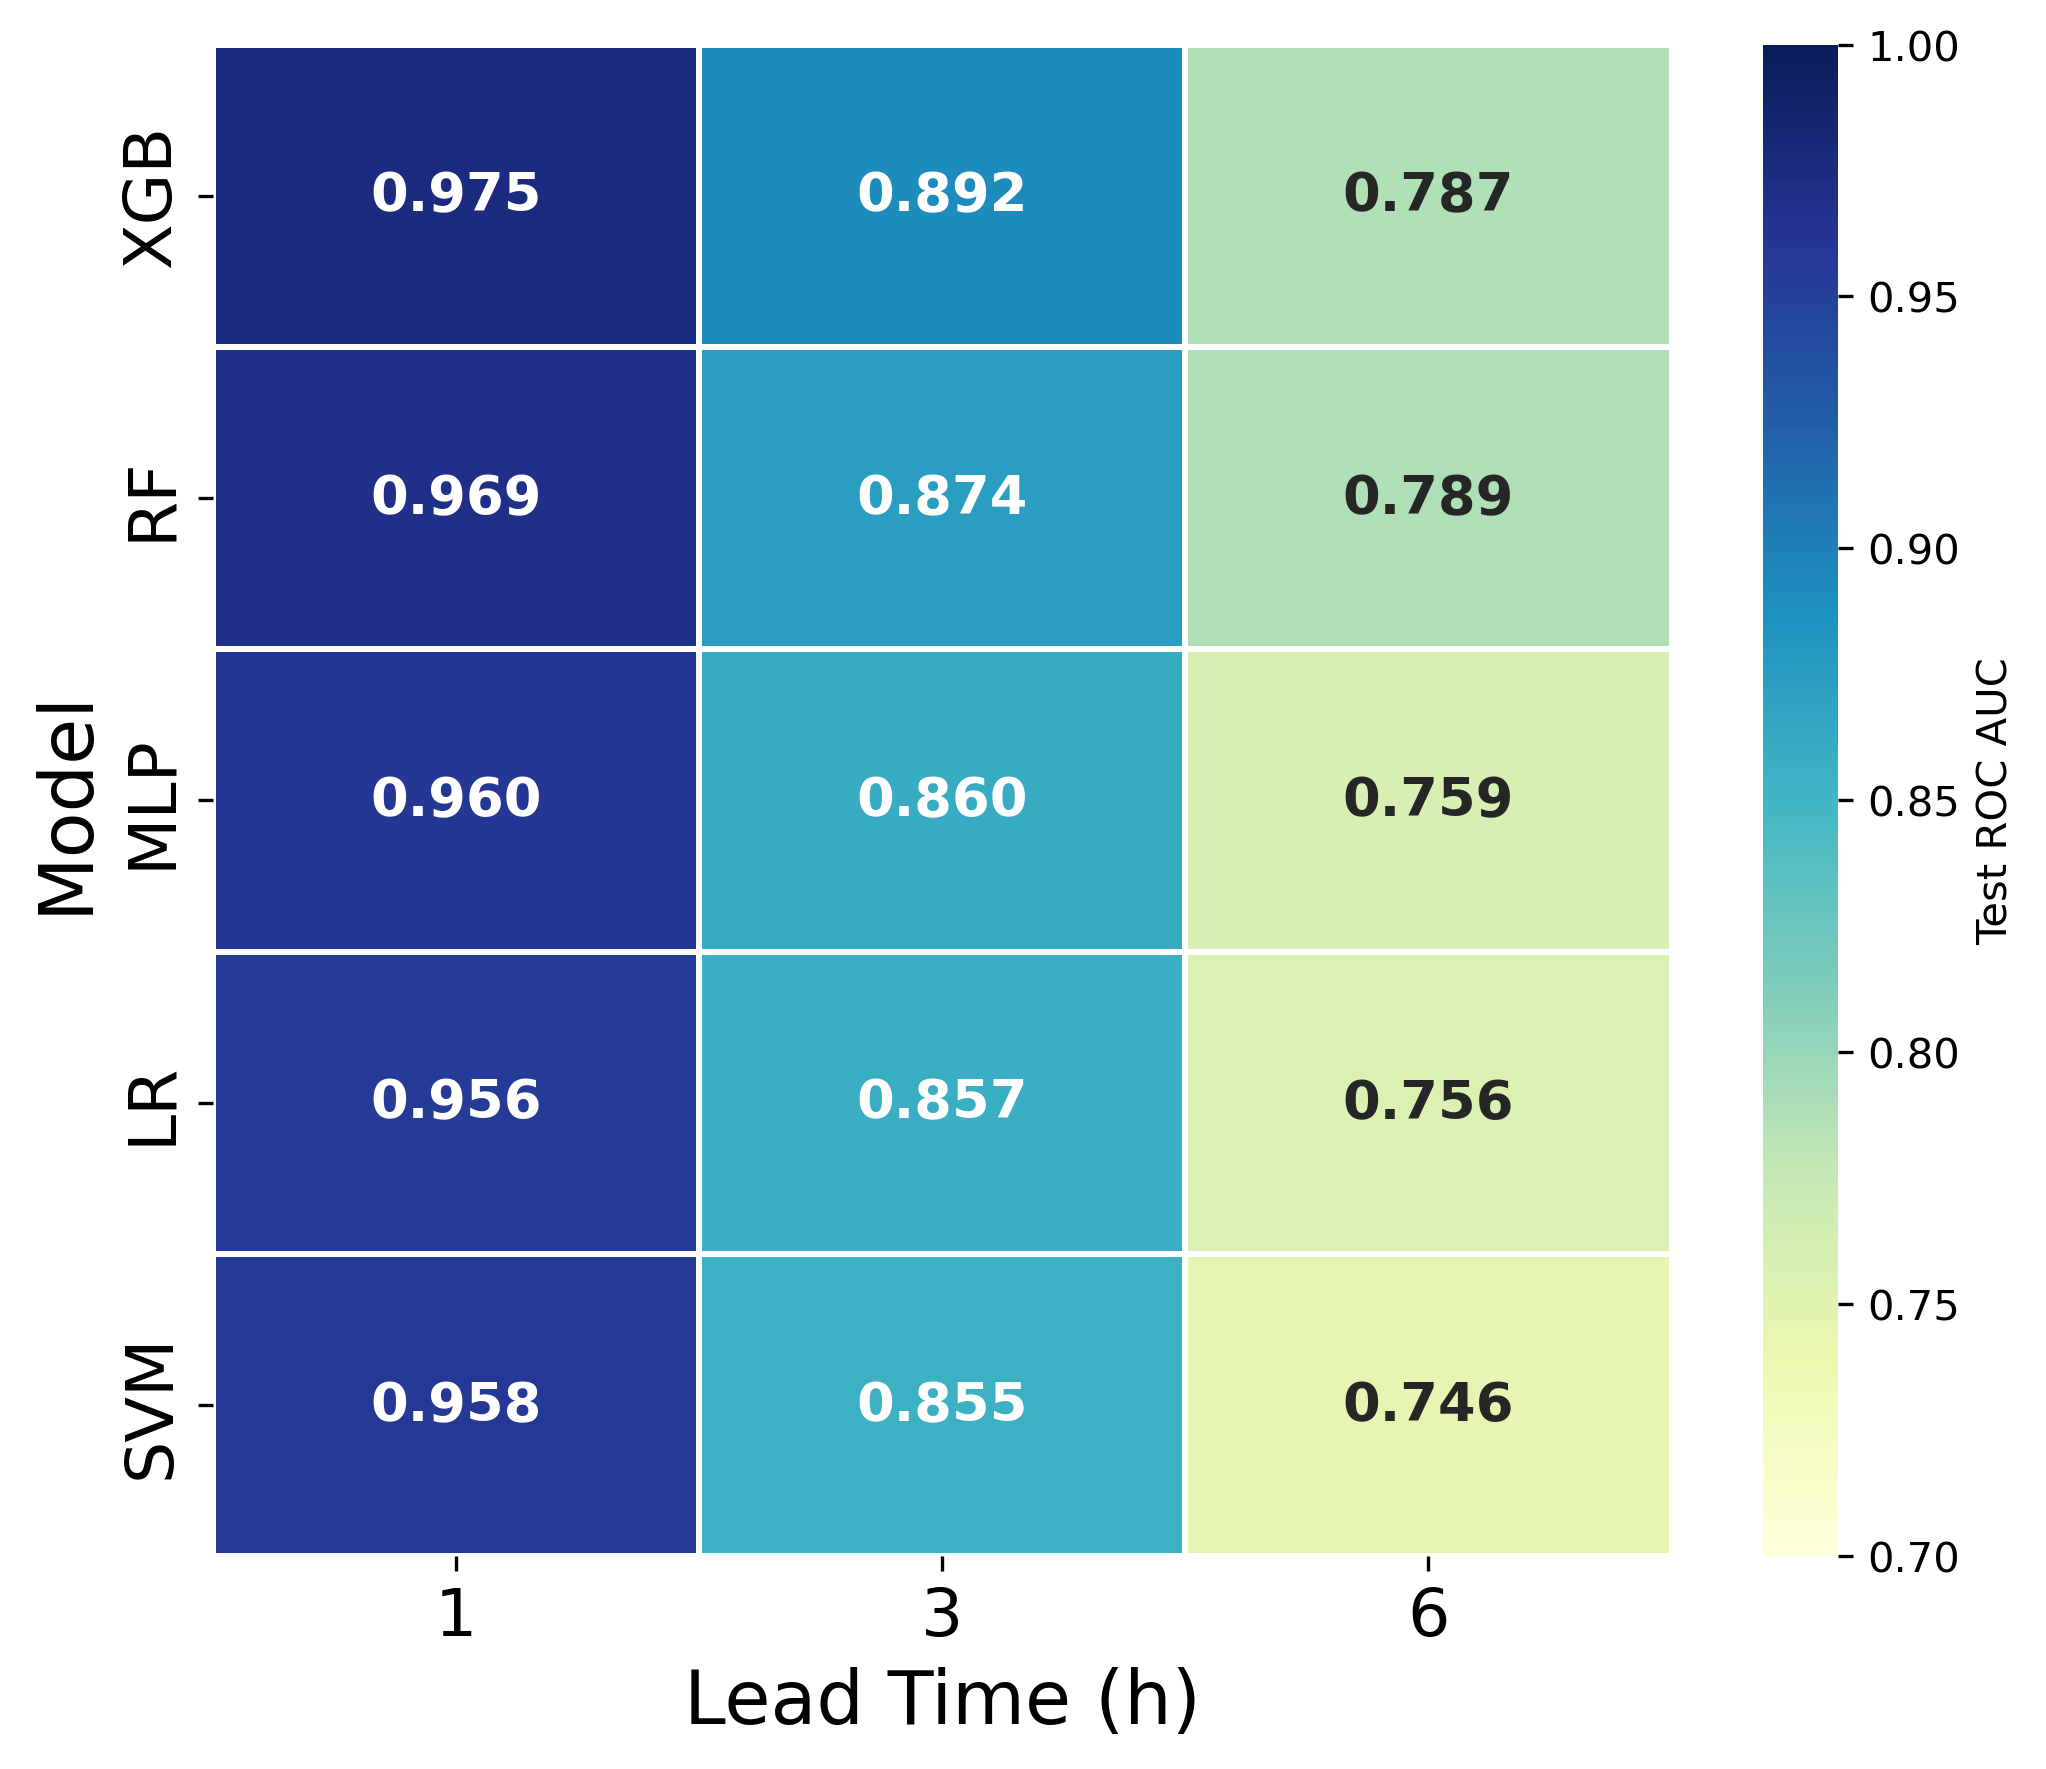

In [9]:
heatmap_df = results.pivot_table(
    index="model",
    columns="lead_time",
    values="test_auc"
)

model_order = [
    "XGB",
    "RF",
    "MLP",
    "LR",
    "SVM"
]

heatmap_df = heatmap_df.reindex(model_order)


plt.figure(figsize=(7, 6), dpi=300)


sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    annot_kws={
        "fontsize": 13,
        "fontweight": "bold"
    },
    vmin=0.7,
    vmax=1,
    cbar_kws={
        "label": "Test ROC AUC"
    }
)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.xlabel("Lead Time (h)", fontsize=18)
plt.ylabel("Model", fontsize=18)

plt.tight_layout()

plt.show()

In [10]:
heatmap_df

lead_time,1,3,6
model,,,
XGB,0.974685,0.891744,0.786966
RF,0.968629,0.873776,0.788869
MLP,0.960046,0.859663,0.758832
LR,0.955923,0.857421,0.755624
SVM,0.957932,0.855442,0.745549
